In [61]:
# Installation des dépendances
! pip install pandas numpy matplotlib scikit-learn lightgbm seaborn openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]


In [1]:
# Dépendences
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.patches import Rectangle
from lightgbm import LGBMClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    average_precision_score,
    precision_recall_curve,
)

In [2]:
# Importer les données et déposéer dans le root du projet
# Données disponibles sur : https://www.cryptoarchive.com.au/

cols = [
    "timestamp",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "close_time",
    "quote_asset_volume",
    "trades",
    "ignore",
]
df = pd.read_csv(
    "BTCUSDT.csv",
    sep="|",
    header=None,
    names=cols,
    usecols=["timestamp", "open", "high", "low", "close", "volume"],
)

df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
df = df.set_index("timestamp")
df

,open,high,low,close,volume
timestamp,,,,,
2017-08-17 04:00:00,4261.48,4261.48,4261.48,4261.48,1.775183
2017-08-17 04:01:00,4261.48,4261.48,4261.48,4261.48,0.000000
2017-08-17 04:02:00,4280.56,4280.56,4280.56,4280.56,0.261074
2017-08-17 04:03:00,4261.48,4261.48,4261.48,4261.48,0.012008
2017-08-17 04:04:00,4261.48,4261.48,4261.48,4261.48,0.140796
...,...,...,...,...,...
2026-04-21 15:42:00,75676.99,75712.00,75657.89,75712.00,7.672540
2026-04-21 15:43:00,75712.66,75746.47,75712.66,75732.47,5.510390
2026-04-21 15:44:00,75732.48,75763.03,75701.50,75701.50,5.428980


**Cible binaire**
- `y=1` : la volatilité du prochain horizon est dans le top `percentile` de la journée (instabilité)
- `y=0` : pas d'instabilité

La volatilité est mesurée par l'écart-type des log-returns $\log(p_t / p_{t-1})$ sur la fenêtre suivante. Le seuil est dynamique (percentile glissant sur 24h) pour s'adapter aux changements de régime de BTC.

**Paramètres clés**
- `candles_window` : horizon en candles (ex. 120 candles = 2h avec des candles de 1m)
- `stride` : sous-échantillonnage — garder 1 observation toutes les `stride` candles pour réduire la redondance sans perdre d'information (ex. `stride=60` → 1 obs/heure)
- `target_only=True` : mode prédiction, ne génère pas la cible

In [3]:
def build_dataset(
    raw_df: pd.DataFrame,
    candles_window: int,
    stride: int,
    quantile_thr: float,
    target_only=False,
) -> tuple[pd.DataFrame, pd.Series | None]:
    eps = 1e-8
    idx = raw_df.index

    # --- Prix de base et log-prix ---
    close = raw_df["close"].astype("float64")
    high = raw_df["high"].astype("float64")
    low = raw_df["low"].astype("float64")
    open_ = raw_df["open"].astype("float64")

    log_close = np.log(close)
    log_open = np.log(open_)
    log_high = np.log(high)
    log_low = np.log(low)

    log_ret = log_close.diff()
    abs_ret = log_ret.abs()
    hl = log_high - log_low
    log_co = log_close - log_open

    half_window = max(2, candles_window // 2)
    double_window = candles_window * 2
    regime_window = max(100, candles_window * 10)

    # --- Volatilité roulante (plusieurs horizons) ---
    vol_w = log_ret.rolling(candles_window).std().rename("vol")
    vol_half = log_ret.rolling(half_window).std().rename(f"vol_{half_window}")
    vol_double = log_ret.rolling(double_window).std().rename(f"vol_{double_window}")

    absret_w = abs_ret.rolling(candles_window).mean().rename("absret")
    absret_half = abs_ret.rolling(half_window).mean().rename(f"absret_{half_window}")
    absret_double = (
        abs_ret.rolling(double_window).mean().rename(f"absret_{double_window}")
    )

    # --- Momentum et range ---
    momentum_w = close.pct_change(candles_window).rename("momentum")
    trend_strength_10 = close.pct_change(10).abs().rename("trend_strength")
    range_w = (((high - low) / close).rolling(candles_window).mean()).rename("range")

    # --- Estimateurs de volatilité haute-basse (Garman-Klass, Parkinson, Rogers-Satchell) ---
    gk_var = 0.5 * hl.pow(2) - (2 * np.log(2) - 1) * log_co.pow(2)
    gk = gk_var.rolling(candles_window).mean().clip(lower=0).pow(0.5).rename("gk")

    parkinson_var = hl.pow(2) / (4 * np.log(2))
    parkinson = (
        parkinson_var.rolling(candles_window)
        .mean()
        .clip(lower=0)
        .pow(0.5)
        .rename("parkinson")
    )

    rs_var = (log_high - log_close) * (log_high - log_open) + (log_low - log_close) * (
        log_low - log_open
    )
    rogers_satchell = (
        rs_var.rolling(candles_window)
        .mean()
        .clip(lower=0)
        .pow(0.5)
        .rename("rogers_satchell")
    )

    # --- Structure de la volatilité ---
    volvol = vol_w.rolling(candles_window).std().rename("volvol")
    vol_ratio = (vol_half / (vol_double + eps)).rename("vol_ratio")
    vol_diff = (vol_half - vol_double).rename("vol_diff")

    # --- Moments statistiques des rendements ---
    skew = log_ret.rolling(candles_window).skew().rename("skew")
    kurt = log_ret.rolling(candles_window).kurt().rename("kurt")

    neg_ret = log_ret.where(log_ret < 0, 0.0)
    pos_ret = log_ret.where(log_ret > 0, 0.0)
    down_vol = neg_ret.rolling(candles_window).std().rename("down_vol")
    up_vol = pos_ret.rolling(candles_window).std().rename("up_vol")
    vol_ratio_ud = (up_vol / (down_vol + eps)).rename("vol_ratio_ud")

    # --- Tendance (MACD normalisé) ---
    ema_fast = close.ewm(span=12, adjust=False).mean()
    ema_slow = close.ewm(span=26, adjust=False).mean()
    ema_diff = ((ema_fast - ema_slow) / close).rename("ema_diff")

    # --- Structure de la bougie ---
    candle_body = ((close - open_) / close).rename("candle_body")
    upper_wick = ((high - np.maximum(close, open_)) / close).rename("upper_wick")
    lower_wick = ((np.minimum(close, open_) - low) / close).rename("lower_wick")

    # --- Détection de régime de volatilité ---
    rolling_vol = vol_w
    vol_mean = rolling_vol.rolling(regime_window).mean()
    vol_std = rolling_vol.rolling(regime_window).std()
    vol_zscore = ((rolling_vol - vol_mean) / (vol_std + eps)).rename("vol_zscore")
    high_vol_regime = (vol_zscore > 1.0).astype("float64").rename("high_vol_regime")

    # --- Autocorrélations et features décalées ---
    autocorr_cols = [
        log_ret.rolling(candles_window)
        .corr(log_ret.shift(lag))
        .rename(f"autocorr_{lag}")
        for lag in (1, 2, 3, 5)
    ]
    lag_cols = [
        vol_w.shift(lag).rename(f"vol_lag_{lag}") for lag in (1, 2, 3, 5, 10)
    ] + [log_ret.shift(lag).rename(f"log_ret_lag_{lag}") for lag in (1, 2, 3, 5, 10)]

    X = pd.concat(
        [
            log_ret.rename("log_ret"),
            vol_w,
            absret_w,
            momentum_w,
            range_w,
            gk,
            parkinson,
            rogers_satchell,
            volvol,
            vol_half,
            vol_double,
            absret_half,
            absret_double,
            vol_ratio,
            vol_diff,
            skew,
            kurt,
            down_vol,
            up_vol,
            vol_ratio_ud,
            ema_diff,
            trend_strength_10,
            candle_body,
            upper_wick,
            lower_wick,
            vol_zscore,
            high_vol_regime,
            *lag_cols,
            *autocorr_cols,
        ],
        axis=1,
    ).reindex(idx)

    # --- Normalisation z-score roulante ---
    rolling_mean = X.rolling(candles_window).mean()
    rolling_std = X.rolling(candles_window).std()
    X = (X - rolling_mean) / (rolling_std + eps)

    # --- Cible : volatilité future binaire ---
    if not target_only:
        future_vol = log_ret.rolling(candles_window).std().shift(-candles_window)
        thr = future_vol.rolling(24 * 60).quantile(quantile_thr)
        y = (future_vol >= thr).astype(int).rename("volatility")

        valid_idx = X.notna().all(axis=1) & y.notna()
        X = X.loc[valid_idx]
        y = y.loc[valid_idx]
    else:
        y = None
        valid_idx = X.notna().all(axis=1)
        X = X.loc[valid_idx]

    # --- Sous-échantillonnage par stride ---
    X = X.iloc[::stride]
    if y is not None:
        y = y.iloc[::stride]

    return X, y

Ici on a l'horizon qui regarde les prochains 120 minutes, on sous-échantillones à chaque 60 minutes et on étiquette les observations à volatile (y=1) si leur volatilité future appartient au 10% plus volatile localement (sur une fenêtre glissante de 24h).

Toutes les variables dans X sont normalisées :

In [4]:
WINDOW = 120
STRIDE = WINDOW // 2
PERCENTILE = 0.9

X, y = build_dataset(df, WINDOW, STRIDE, PERCENTILE)
X

,log_ret,vol,absret,momentum,range,gk,parkinson,rogers_satchell,volvol,vol_60,...,vol_lag_10,log_ret_lag_1,log_ret_lag_2,log_ret_lag_3,log_ret_lag_5,log_ret_lag_10,autocorr_1,autocorr_2,autocorr_3,autocorr_5
timestamp,,,,,,,,,,,,,,,,,,,,,
2017-08-18 03:58:00,-0.931602,-1.272196,-1.337860,0.568077,-0.873095,-1.110678,-0.997124,-1.138734,-0.510931,0.858080,...,-1.240260,-0.017452,-0.014969,-0.014969,-0.025736,1.706906,0.128034,0.510198,-1.084023,-0.383245
2017-08-18 04:58:00,-0.015078,0.457704,0.748951,-0.125936,0.104868,-0.355698,-0.016664,-0.590653,-1.522782,-0.974956,...,0.514022,-0.015078,-0.015078,-0.015078,0.137010,-0.012479,0.759835,-1.596021,-0.249539,0.820911
2017-08-18 05:58:00,-0.028608,2.055336,1.228099,0.973474,2.764907,2.526175,2.768792,2.139366,-0.214797,2.887311,...,0.410322,-0.358477,-0.025065,2.977885,-3.122615,0.432432,-0.699210,-1.281133,2.721350,-0.318029
2017-08-18 06:58:00,-1.774173,1.633106,1.902036,-1.327249,1.766245,1.510601,1.556968,1.446399,2.084249,0.072036,...,1.869053,1.162666,-0.000068,-0.000068,-0.000068,-0.002656,-0.931820,0.257359,0.282811,2.265664
2017-08-18 07:58:00,-1.919752,-2.674855,-2.262170,-1.515068,-2.302871,-2.457018,-2.499608,-2.295381,-0.919222,-2.495753,...,-1.510089,1.003615,-0.967693,0.015438,-0.013165,-0.007288,-1.485230,3.051839,-3.345773,2.416007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-21 11:39:00,0.541380,-0.582438,-0.221379,1.034170,-0.801399,-1.146337,-0.964399,-1.256768,0.984462,1.255352,...,-0.799130,-0.649344,-0.771677,1.771592,-2.382454,0.283192,1.103608,0.131991,0.939001,-2.510291
2026-04-21 12:39:00,-3.838556,2.371153,3.427260,-2.559032,4.183857,1.603118,2.122207,1.207457,-1.228910,1.947755,...,0.372165,-2.571583,-2.344791,0.919696,1.517729,0.382405,0.332625,2.319184,-0.370326,-2.557948
2026-04-21 13:39:00,-1.157957,0.729499,0.707299,-1.307479,1.445517,1.682232,1.303695,1.996446,0.700698,0.028002,...,0.818153,0.346069,-0.660730,0.077696,0.540607,-0.007743,-1.615694,1.234980,-1.655208,1.398837


---
## Visualisation de la cible et du jeu de données brute

In [ ]:
def plot_candles_targets(df, y, start_date, end_date, window, stride):
    s, e = pd.to_datetime(start_date), pd.to_datetime(end_date)

    d = df.loc[s:e, ["open", "high", "low", "close"]].astype(float)
    if d.empty:
        raise ValueError("Empty slice")

    g0 = df.index.get_loc(d.index[0])
    g1 = df.index.get_loc(d.index[-1])
    pos = np.arange(g0, g1 + 1)
    x = pos - g0

    fig, ax = plt.subplots(figsize=(16, 7))
    w = 0.6

    for xi, (_, row) in zip(x, d.iterrows()):
        o, h, l, c = row["open"], row["high"], row["low"], row["close"]
        col = "green" if c >= o else "red"
        ax.vlines(xi, l, h, color=col, lw=1)
        ax.add_patch(
            Rectangle(
                (xi - w / 2, min(o, c)),
                w,
                max(abs(c - o), 1e-12),
                fc=col,
                ec=col,
                lw=0.8,
            )
        )

    first_y = df.index.get_loc(y.index[0])
    for p in range(first_y, len(df), stride):
        if g0 <= p <= g1:
            ax.axvline(p - g0, color="gray", ls="--", lw=1, alpha=0.35)

    pos_y1 = df.index.get_indexer(y[y.eq(1)].index)
    pos_y1 = pos_y1[pos_y1 >= 0]

    for p in pos_y1:
        a, b = p, p + window
        if b < g0 or a > g1:
            continue
        ax.axvspan(max(a, g0) - g0, min(b, g1) - g0, color="red", alpha=0.15)

    plt.title(
        f"Visualisation des candles et des zones volatiles pour la période {start_date} - {end_date}"
    )
    plt.xlabel("Index candle")
    plt.ylabel("Prix (USD)")

    ax.set_xlim(0, len(d) - 1)
    ax.grid(alpha=0.2)
    plt.show()

: 

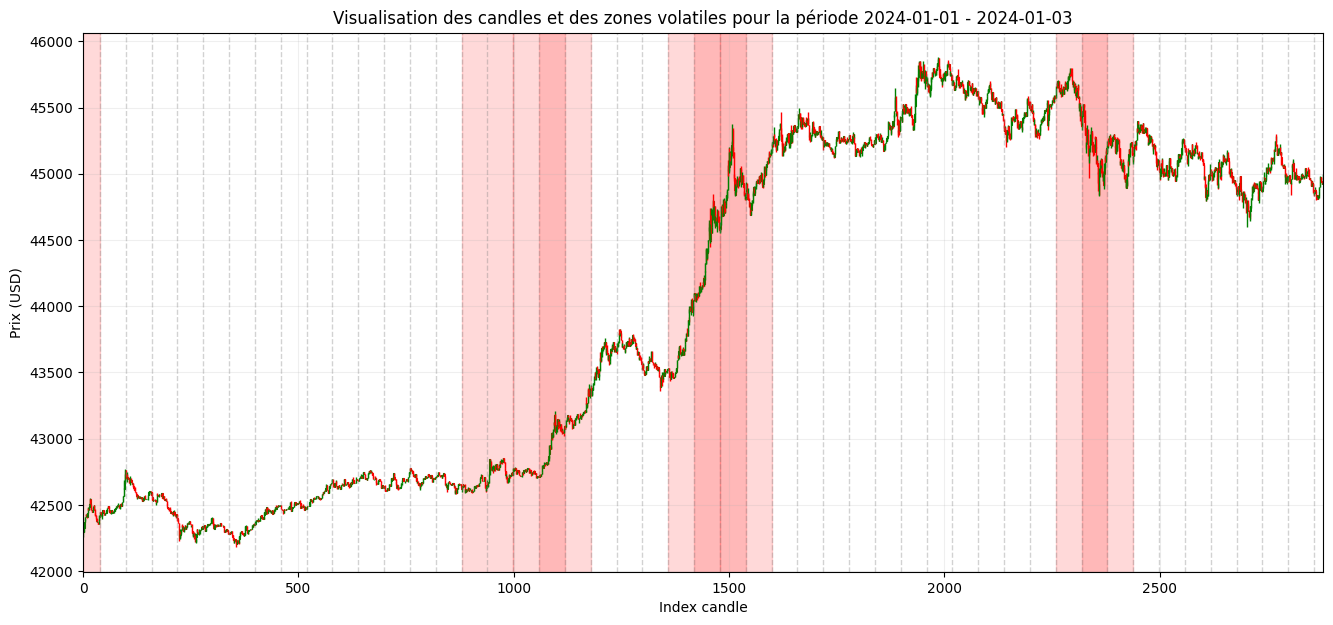

In [37]:
plot_candles_targets(
    df, y, start_date="2024-01-01", end_date="2024-01-03", window=WINDOW, stride=STRIDE
)

Le graphe ci-haut est une représentation de la cible : les lignes verticales grises sont les strides (ou le sous-échantillonage de 60 minutes), en rouge on a les moments de volatilité (pas les cibles mais bien la volatilité détectée donc décalage de WINDOW entre échantillon X et cible y [pour que ca soit plus facile à comprendre graphiquement]).

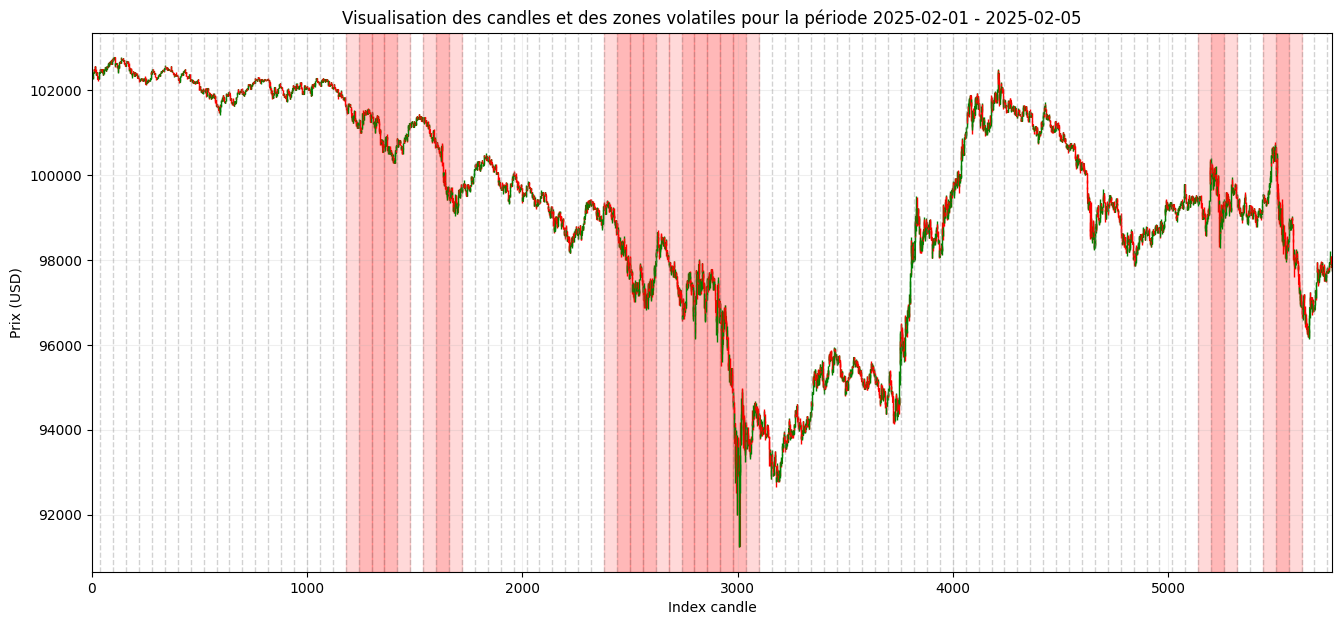

In [38]:
plot_candles_targets(
    df, y, start_date="2025-02-01", end_date="2025-02-05", window=WINDOW, stride=STRIDE
)

L'exemple ici montre la faiblesse/limite de notre cible, on voit un gros "spike" positif (entre 3500 et 4000) pourtant on le considère pas comme cible : très probablement à cause que c'est une croissance plus progressive et moins variable. Notre cible mesure la dispersion (écart type) du log return, pas l'amplitude. Aussi, le percentile 90 a un gros impact ici aussi : puisqu'il y a des gros spikes autour de la monté positive, sa variance est relativement moins importante donc on ne la considère pas comme une zone volatile dans notre cas.

In [62]:
X.describe().T.round(3).to_excel("feature_summary.xlsx")

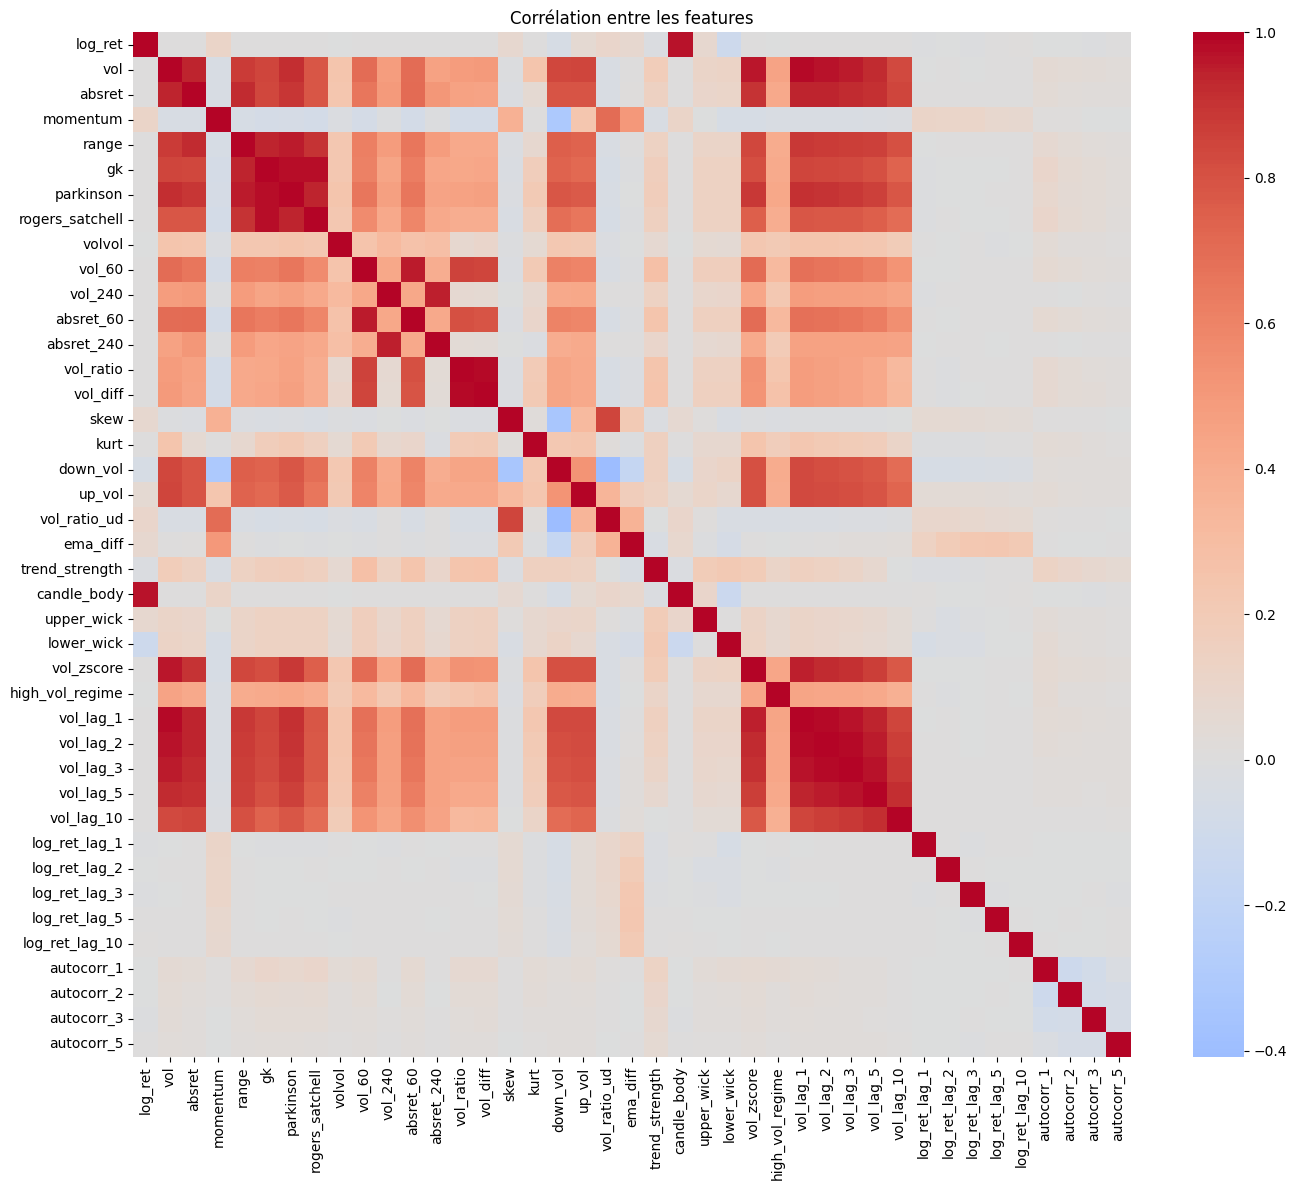

In [ ]:
def feature_correlation_heatmap(X):
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(
        X.corr(), cmap="coolwarm", center=0, ax=ax, xticklabels=True, yticklabels=True
    )
    ax.set_title("Corrélation entre les features")
    plt.tight_layout()
    plt.show()


feature_correlation_heatmap(X)

## Corrélation entre les features

On voit que certaines feature semblent fortement corrélés entre elles ce qui peut suggérer une possible redondance de features.

Un premier bloc regroupe `vol`, `absret`, `range`, `gk`, `parkinson` et `rogers_satchell`, tous mesurant la volatilité réalisée à court terme avec des corrélations supérieures à 0.85.
À l'inverse, certaines features apparaissent quasi-indépendantes du reste : `skew`, `kurt`, `candle_body`, `upper_wick`, `lower_wick` et les `autocorr_*`.

Une solution serait de faire une sélection de feature en se basant sur l'importance des features lors des résultats de nos modèles. Il serait également possble d'utiliser une PCA pour décorréler les features.

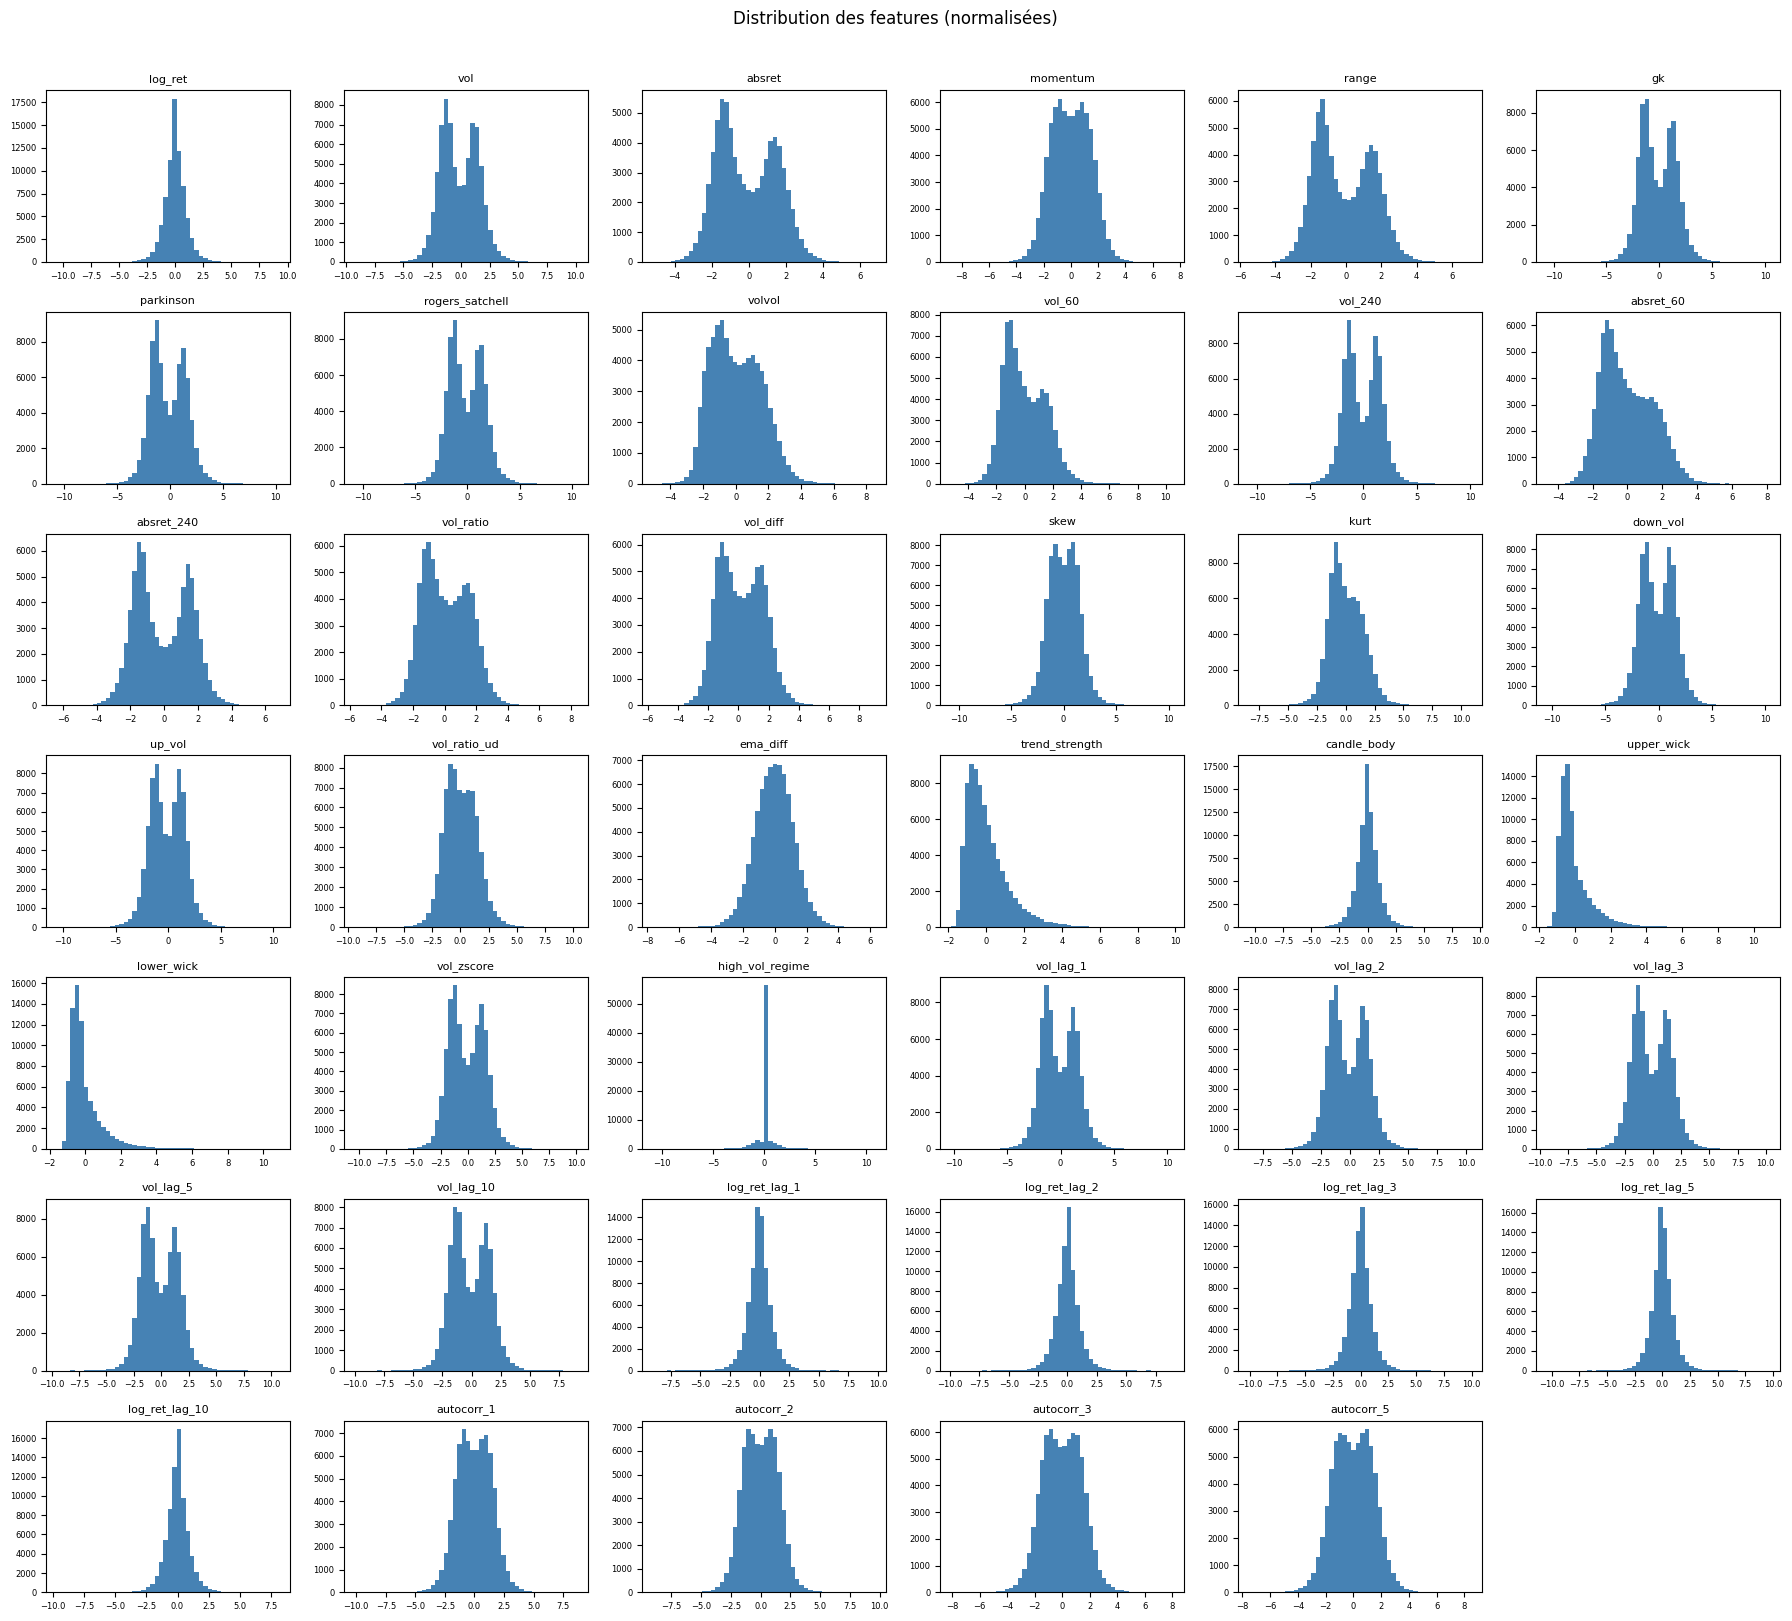

In [ ]:
def plot_feature_distributions(X):
    fig, axes = plt.subplots(7, 6, figsize=(18, 16))
    axes = axes.flatten()

    for i, col in enumerate(X.columns):
        axes[i].hist(X[col].dropna(), bins=50, color="steelblue", edgecolor="none")
        axes[i].set_title(col, fontsize=8)
        axes[i].tick_params(labelsize=6)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Distribution des features (normalisées)", y=1.01)
    plt.tight_layout()
    plt.show()

def plot_key_feature_distributions(X):
    features = ["ema_diff", "vol", "lower_wick"]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for ax, col in zip(axes, features):
        ax.hist(X[col].dropna(), bins=50, color="steelblue", edgecolor="none")
        ax.set_title(col, fontsize=10)
        ax.tick_params(labelsize=8)

    plt.suptitle("Distribution des features clés (normalisées)")
    plt.tight_layout()
    plt.show()


plot_key_feature_distributions(X)
plot_feature_distributions(X)

### Distribution des features
Les distributions normalisées révèlent trois profils distincts :
1. Distribution bimodale (`vol`, `parkinson`), ce qui pourrait être causé par l'existence du passage de la volatilité de haut à bas.
2. Distribution asymétrique à queue lourde (`vol_lag_1`) pourrait être cuasé par la persistance de la volatilité avant de se résorber.
3. Distribution plus centrée (`vol_zscore`), résultat direct de sa construction.

---
## Apprentissage et évaluation de modèles

In [41]:
def evaluate_timeseries_cv_proba(titre, all_y_true, all_y_proba, top_k=0.1):
    print(f"\n=== Évaluation de {titre} ===")
    y_true = np.concatenate([np.asarray(y).astype(int) for y in all_y_true])
    y_proba = np.concatenate([np.asarray(p, dtype=float) for p in all_y_proba])

    if y_true.shape[0] != y_proba.shape[0]:
        raise ValueError("y_true and y_proba must have the same length")
    if not (0 < top_k < 1):
        raise ValueError("k_frac must be in (0, 1)")

    threshold = np.quantile(y_proba, 1 - top_k)
    y_pred = (y_proba >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    im = axes[0].imshow(cm, cmap="Blues")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title(f"Confusion Matrix (top {int(top_k * 100)}%)")

    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm[i, j], ha="center", va="center", color="grey")

    plt.colorbar(im, ax=axes[0])

    axes[1].plot(recall_curve, precision_curve, label=f"PR-AUC = {pr_auc:.4f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve")
    axes[1].legend()
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    print(f"n_samples          : {len(y_true)}")
    print(f"top_k_frac         : {top_k:.2f}")
    print(f"threshold          : {threshold:.4f}")
    print(
        f"precision          : {precision_score(y_true, y_pred, zero_division=0):.4f}"
    )
    print(f"recall             : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"pr_auc             : {pr_auc:.4f}")
    print(f"P(y=1) [Baseline]  : {np.mean(all_y_true):.4f}")

In [42]:
def purged_kfold_splits(X, t1, n_splits=5, embargo_pct=0.01):
    indices = np.arange(len(X))
    embargo = int(len(X) * embargo_pct)

    splits = []

    for train_raw, test_raw in TimeSeriesSplit(n_splits=n_splits).split(X):
        test_start_time = X.index[test_raw[0]]
        embargo_cutoff = max(0, test_raw[0] - embargo)

        train_idx = [
            i for i in indices[:embargo_cutoff] if t1.iloc[i] < test_start_time
        ]
        splits.append((train_idx, list(test_raw)))

    return splits


def compute_mda(model, X, y):
    result = permutation_importance(
        model, X, y, n_repeats=5, scoring="average_precision", random_state=42
    )
    return pd.Series(result.importances_mean, index=X.columns).sort_values(
        ascending=False
    )


def plot_mda(feat_importance_mean, title):
    feat_importance_mean.plot(kind="bar", figsize=(14, 4), title=f"MDA - {title}")
    plt.tight_layout()
    plt.show()


def performance_by_fold(i, X_test, y_test, proba, top_k):
    thr = np.quantile(proba, 1 - top_k)
    y_pred = (proba >= thr).astype(int)
    fold_precision = precision_score(y_test.values, y_pred, zero_division=0)
    fold_auc = average_precision_score(y_test.values, proba)
    if i == 0:
        print("=== Performance par fold ===")
    print(
        f"  Fold {i+1} | {X_test.index[0].date()} → {X_test.index[-1].date()} | precision={fold_precision:.3f} | pr_auc={fold_auc:.3f}"
    )


def trainAndEvaluate(
    titre, X, y, model_class, train_on_all_data=False, top_k=0.01, **kwargs
):
    all_y_true = []
    all_y_proba = []
    feat_importance = []

    t1 = X.index.to_series() + pd.Timedelta(minutes=WINDOW)

    for i, (train_idx, test_idx) in enumerate(purged_kfold_splits(X, t1, n_splits=5)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = model_class(**kwargs)
        model.fit(X_train, y_train)

        proba = model.predict_proba(X_test)[:, 1]

        all_y_true.append(y_test.values)
        all_y_proba.append(proba)

        feat_importance.append(compute_mda(model, X_test, y_test))
        performance_by_fold(i, X_test, y_test, proba, top_k)

    evaluate_timeseries_cv_proba(titre, all_y_true, all_y_proba, top_k=top_k)
    plot_mda(pd.DataFrame(feat_importance).mean().sort_values(ascending=False), titre)

    if train_on_all_data:
        model = model_class(**kwargs)
        model.fit(X, y)

        return model

    return None

### GBM - sklearn

=== Performance par fold ===
  Fold 1 | 2019-01-30 → 2020-07-12 | precision=0.409 | pr_auc=0.175
  Fold 2 | 2020-07-12 → 2021-12-22 | precision=0.425 | pr_auc=0.199
  Fold 3 | 2021-12-22 → 2023-06-02 | precision=0.504 | pr_auc=0.215
  Fold 4 | 2023-06-02 → 2024-11-10 | precision=0.559 | pr_auc=0.273
  Fold 5 | 2024-11-10 → 2026-04-21 | precision=0.669 | pr_auc=0.339

=== Évaluation de GBM - SKlearn ===


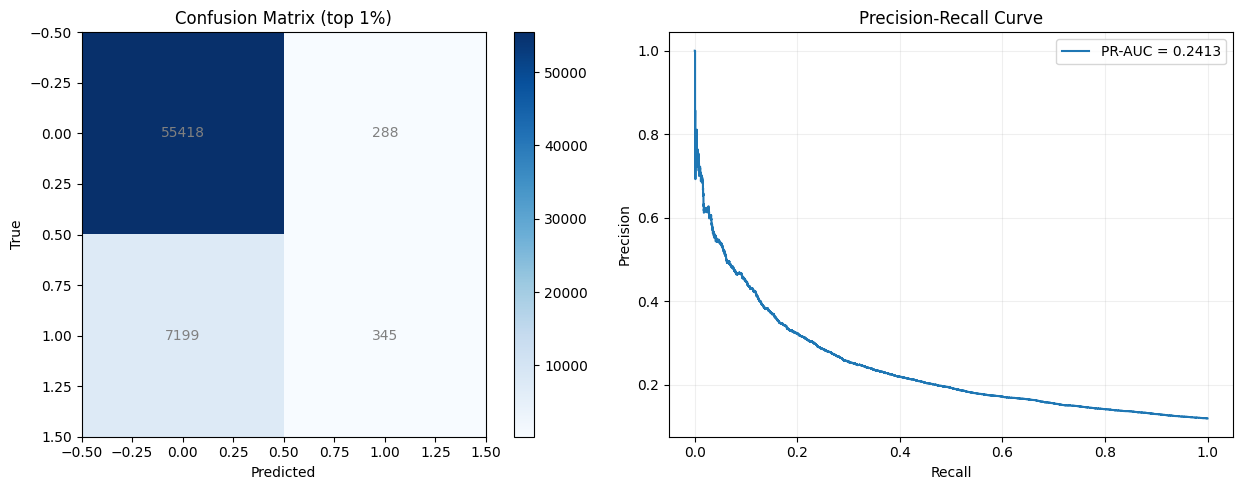

n_samples          : 63250
top_k_frac         : 0.01
threshold          : 0.7961
precision          : 0.5450
recall             : 0.0457
pr_auc             : 0.2413
P(y=1) [Baseline]  : 0.1193


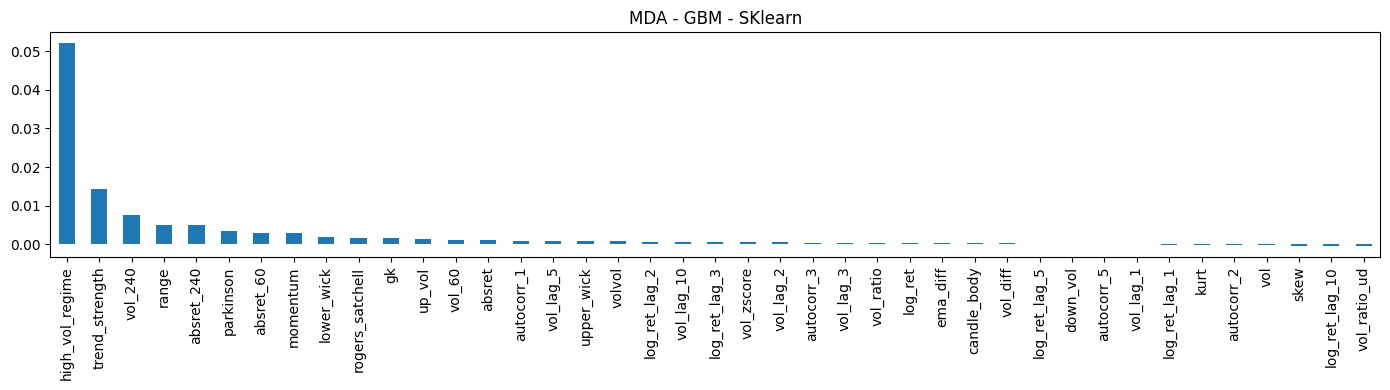

In [43]:
trainAndEvaluate(
    "GBM - SKlearn",
    X,
    y,
    HistGradientBoostingClassifier,
    top_k=0.01,
    class_weight="balanced",
    random_state=42,
)

### GBM LightGBM

=== Performance par fold ===
  Fold 1 | 2019-01-30 → 2020-07-12 | precision=0.402 | pr_auc=0.177
  Fold 2 | 2020-07-12 → 2021-12-22 | precision=0.402 | pr_auc=0.192
  Fold 3 | 2021-12-22 → 2023-06-02 | precision=0.528 | pr_auc=0.212
  Fold 4 | 2023-06-02 → 2024-11-10 | precision=0.575 | pr_auc=0.274
  Fold 5 | 2024-11-10 → 2026-04-21 | precision=0.614 | pr_auc=0.320

=== Évaluation de GBM - LightGBM ===


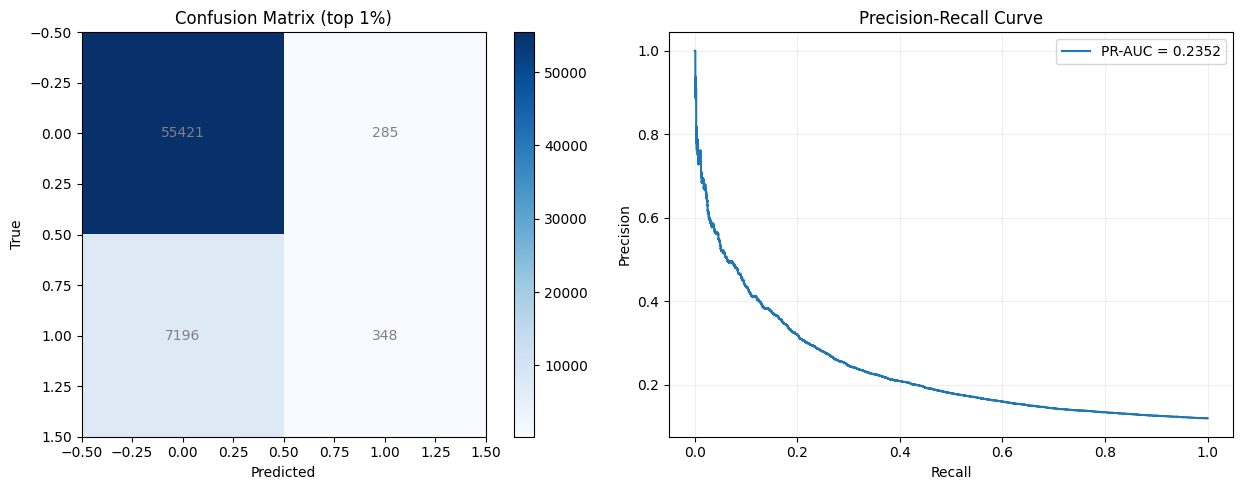

n_samples          : 63250
top_k_frac         : 0.01
threshold          : 0.7820
precision          : 0.5498
recall             : 0.0461
pr_auc             : 0.2352
P(y=1) [Baseline]  : 0.1193


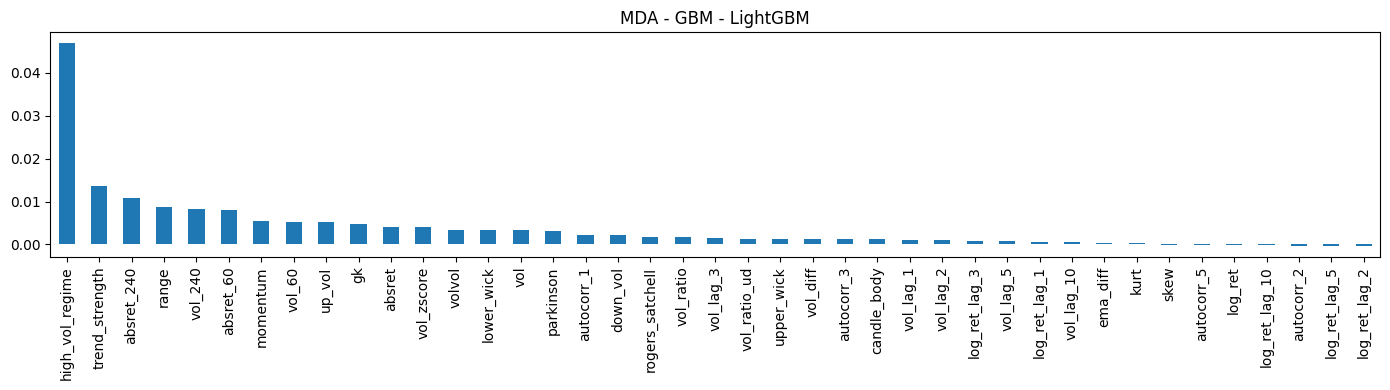

In [44]:
lgbm = trainAndEvaluate(
    "GBM - LightGBM",
    X,
    y,
    LGBMClassifier,
    train_on_all_data=True,
    top_k=0.01,
    objective="binary",
    class_weight="balanced",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1,
)

### Forêt Aléatoire

=== Performance par fold ===
  Fold 1 | 2019-01-30 → 2020-07-12 | precision=0.361 | pr_auc=0.161
  Fold 2 | 2020-07-12 → 2021-12-22 | precision=0.369 | pr_auc=0.177
  Fold 3 | 2021-12-22 → 2023-06-02 | precision=0.463 | pr_auc=0.202
  Fold 4 | 2023-06-02 → 2024-11-10 | precision=0.503 | pr_auc=0.241
  Fold 5 | 2024-11-10 → 2026-04-21 | precision=0.631 | pr_auc=0.296

=== Évaluation de Forêt Aléatoire - SKlearn ===


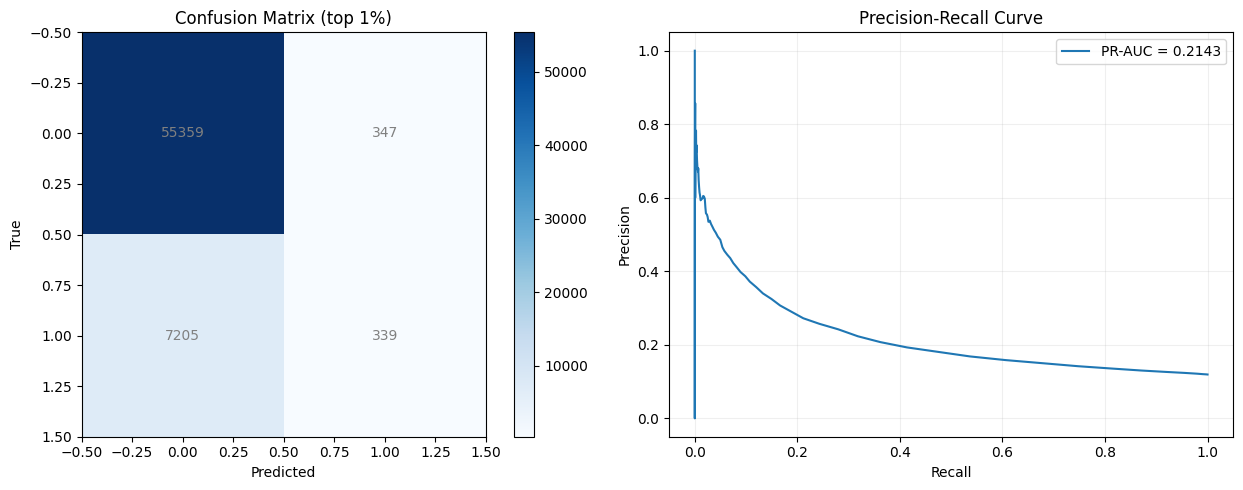

n_samples          : 63250
top_k_frac         : 0.01
threshold          : 0.3500
precision          : 0.4942
recall             : 0.0449
pr_auc             : 0.2143
P(y=1) [Baseline]  : 0.1193


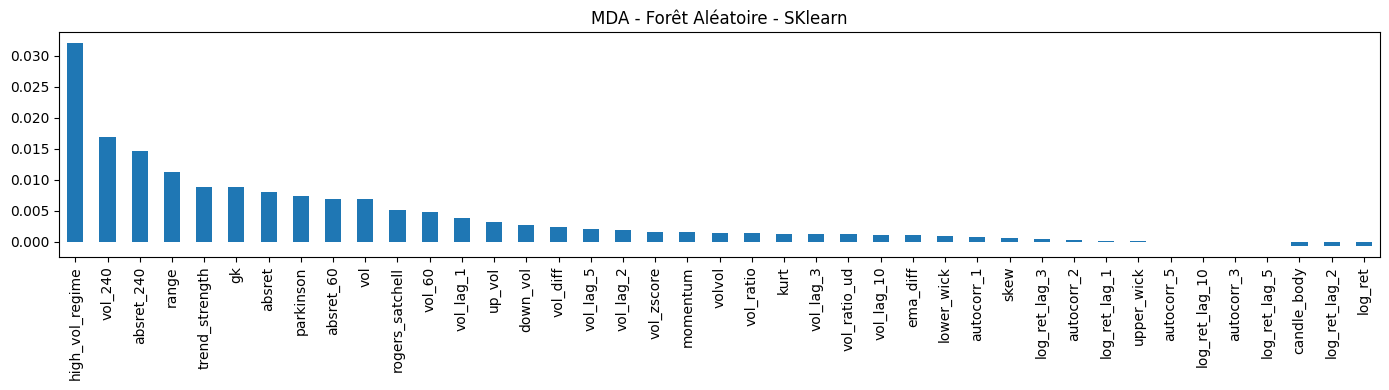

In [45]:
trainAndEvaluate(
    "Forêt Aléatoire - SKlearn",
    X,
    y,
    RandomForestClassifier,
    top_k=0.01,
    class_weight="balanced",
    random_state=42,
)

### KNN

=== Performance par fold ===
  Fold 1 | 2019-01-30 → 2020-07-12 | precision=0.379 | pr_auc=0.153
  Fold 2 | 2020-07-12 → 2021-12-22 | precision=0.303 | pr_auc=0.166
  Fold 3 | 2021-12-22 → 2023-06-02 | precision=0.365 | pr_auc=0.175
  Fold 4 | 2023-06-02 → 2024-11-10 | precision=0.504 | pr_auc=0.223
  Fold 5 | 2024-11-10 → 2026-04-21 | precision=0.563 | pr_auc=0.277

=== Évaluation de KNN - SKlearn ===


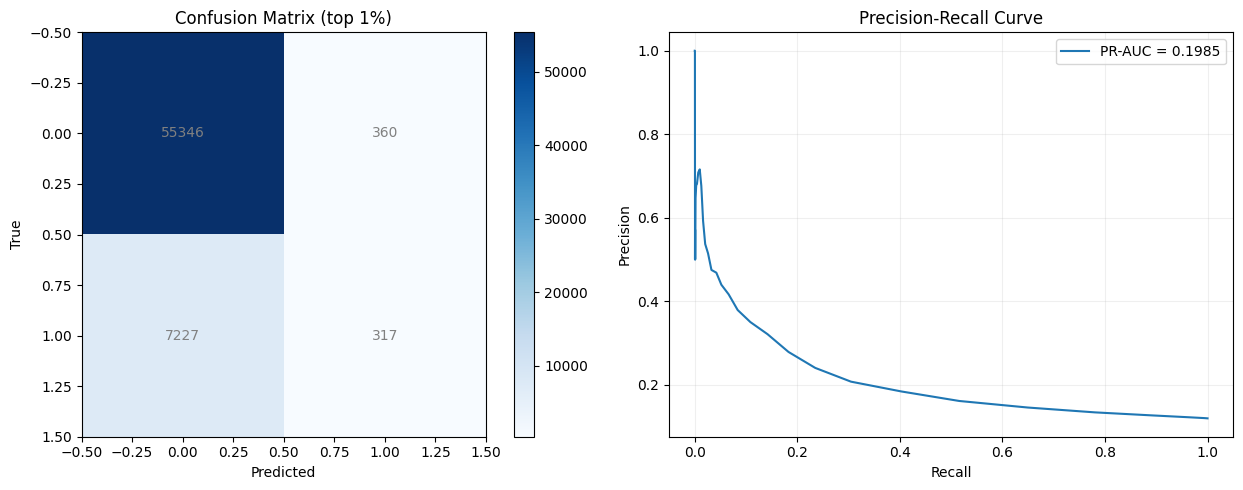

n_samples          : 63250
top_k_frac         : 0.01
threshold          : 0.3137
precision          : 0.4682
recall             : 0.0420
pr_auc             : 0.1985
P(y=1) [Baseline]  : 0.1193


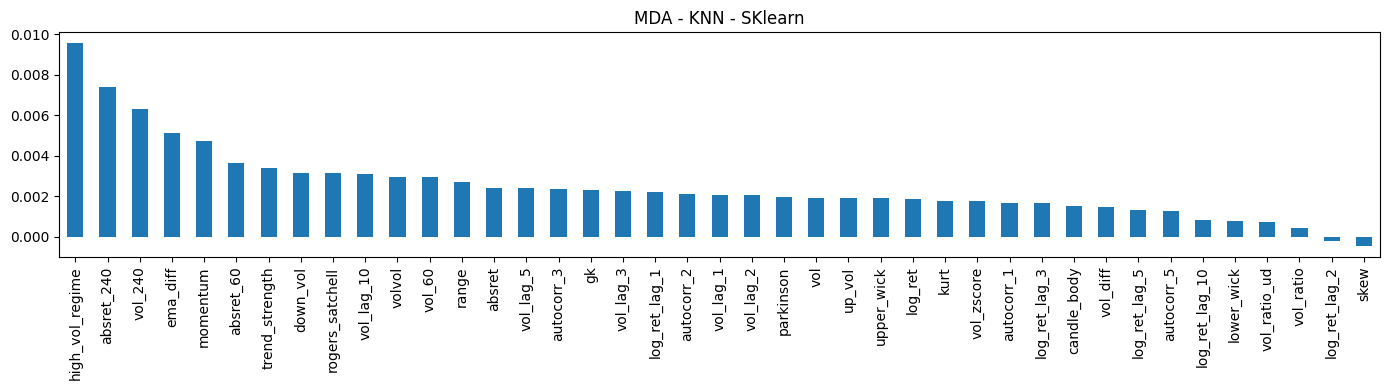

In [46]:
trainAndEvaluate(
    "KNN - SKlearn", X, y, KNeighborsClassifier, top_k=0.01, n_neighbors=51
)

---
### Performance sur un autre jeu de données : SOL/USDT

In [47]:
def loadCryptoCSV(filepath: str):
    cols = [
        "timestamp",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "close_time",
        "quote_asset_volume",
        "trades",
        "ignore",
    ]
    new_df = pd.read_csv(
        filepath,
        sep="|",
        header=None,
        names=cols,
        usecols=["timestamp", "open", "high", "low", "close", "volume"],
    )

    new_df["timestamp"] = pd.to_datetime(new_df["timestamp"], unit="s")
    new_df = new_df.set_index("timestamp")

    return new_df

In [48]:
sol_df = loadCryptoCSV("SOLUSDT.csv")
X_sol, y_sol = build_dataset(sol_df, WINDOW, STRIDE, PERCENTILE)


=== Évaluation de GBM lightgbm entrainné sur BTC pour SOL ===


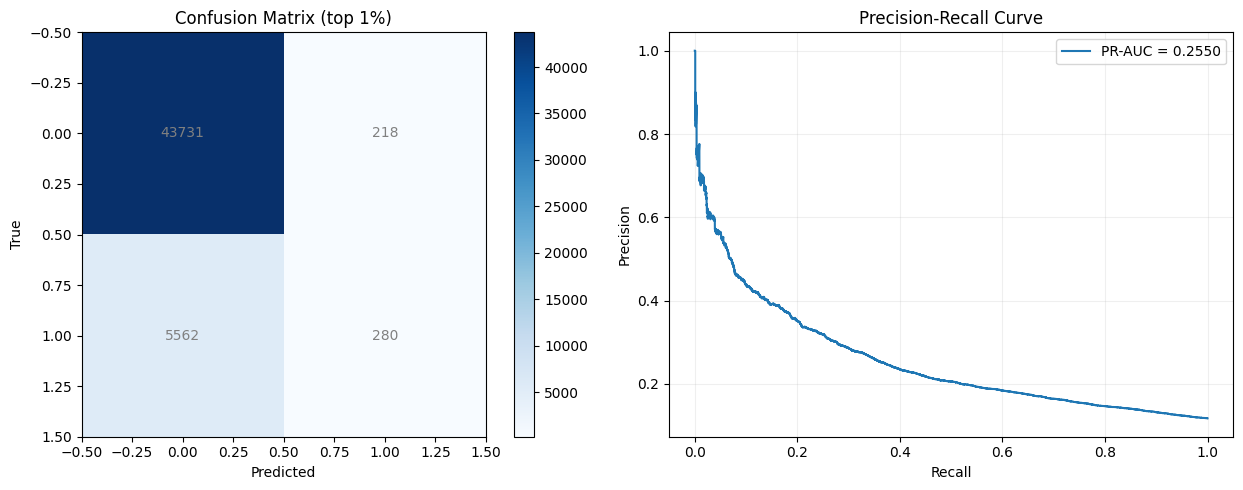

n_samples          : 49791
top_k_frac         : 0.01
threshold          : 0.8232
precision          : 0.5622
recall             : 0.0479
pr_auc             : 0.2550
P(y=1) [Baseline]  : 0.1173


In [49]:
proba = lgbm.predict_proba(X_sol)[:, 1]
evaluate_timeseries_cv_proba(
    "GBM lightgbm entrainné sur BTC pour SOL", [y_sol], [proba], top_k=0.01
)

---
### Performance sur un autre jeu de données : ETH/USDT

In [50]:
eth_df = loadCryptoCSV("ETHUSDT.csv")
X_eth, y_eth = build_dataset(eth_df, WINDOW, STRIDE, PERCENTILE)


=== Évaluation de GBM lightgbm entrainné sur BTC pour ETH ===


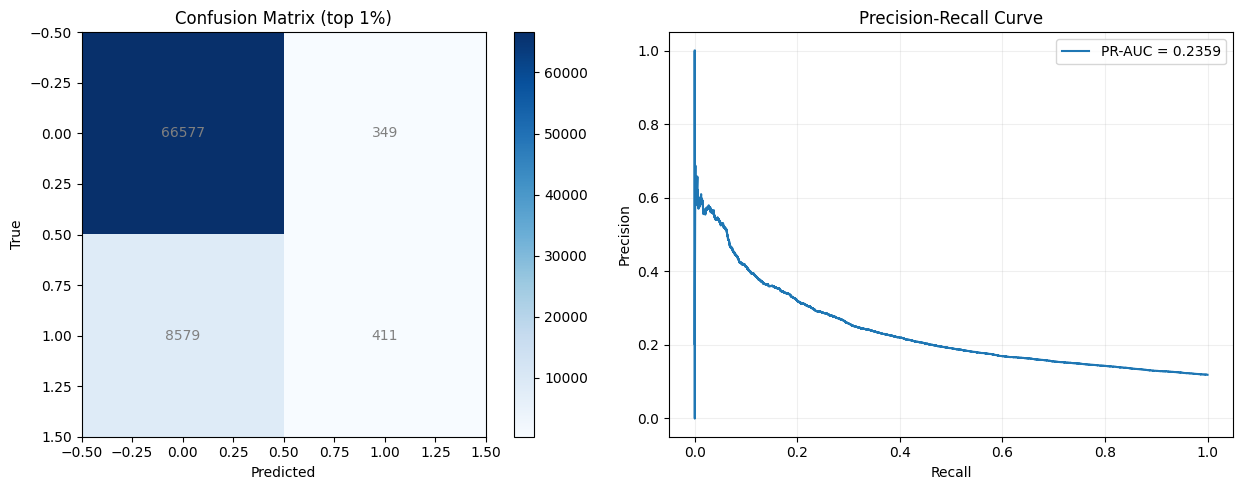

n_samples          : 75916
top_k_frac         : 0.01
threshold          : 0.8300
precision          : 0.5408
recall             : 0.0457
pr_auc             : 0.2359
P(y=1) [Baseline]  : 0.1184


In [51]:
proba = lgbm.predict_proba(X_eth)[:, 1]
evaluate_timeseries_cv_proba(
    "GBM lightgbm entrainné sur BTC pour ETH", [y_eth], [proba], top_k=0.01
)

---
### Performance sur un autre jeu de données : SUI/USDT

In [52]:
sui_df = loadCryptoCSV("SUIUSDT.csv")
X_sui, y_sui = build_dataset(sui_df, WINDOW, STRIDE, PERCENTILE)


=== Évaluation de GBM lightgbm entrainné sur BTC pour SUI ===


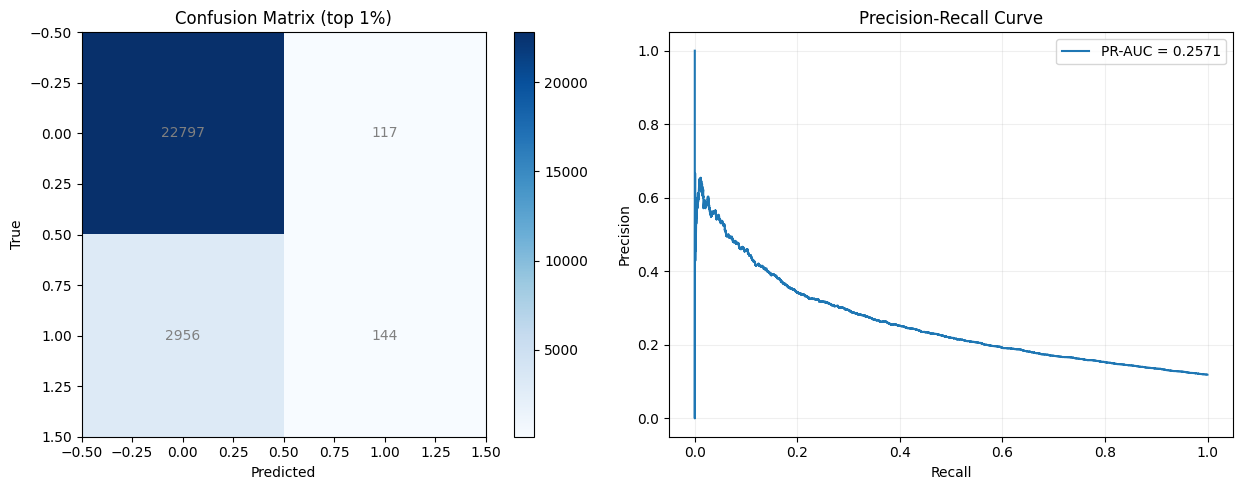

n_samples          : 26014
top_k_frac         : 0.01
threshold          : 0.8051
precision          : 0.5517
recall             : 0.0465
pr_auc             : 0.2571
P(y=1) [Baseline]  : 0.1192


In [53]:
proba = lgbm.predict_proba(X_sui)[:, 1]
evaluate_timeseries_cv_proba(
    "GBM lightgbm entrainné sur BTC pour SUI", [y_sui], [proba], top_k=0.01
)

Donc le modèle entrainné sur BTC généralise surprenament bien sur d'autres cryptomonnaies. Soit parce qu'il capture bien les patterns qui explique la volatilité ou car les autres cryptomonnaies reflètent le comportement du Bitcoin.